# Different Ways to Chunk Podcast and PDF

### Step 1: Setup and Data Loading

In [5]:
%pip install langchain langchain-community PyPDF2 python-dotenv openai tiktoken pydub pandas

  Using cached langchain-1.2.17-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached pypdf2-3.0.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached langchain_core-1.3.2-py3-none-any.whl.metadata (4.4 kB)
  Using cached langgraph-1.1.10-py3-none-any.whl.metadata (8.0 kB)
  Using cached langchain_protocol-0.0.14-py3-none-any.whl.metadata (2.4 kB)
  Using cached langsmith-0.8.0-py3-none-any.whl.metadata (15 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached uuid_utils-0.14.1-cp39-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached langgraph_checkpoint-4.0.3-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_prebuilt-1.0.13-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.3.13-py3-none-any.whl.metadata (1.6 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached langchain_classic-1.0.4-py3-none-any.whl.metadata (4.8 kB)


In [6]:
# Import necessary libraries
import os
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI

# Load environment variables from .env file
load_dotenv()

# Initialize OpenAI client
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

# Set default model
MODEL = "gpt-4o-mini"

Uploading podcast audio and transcribe

Note: the audio exceeds the 25MB upload limit. It needs to be split into chunks.

In [3]:
# Transcribe podcast audio and save transcript locally
from pydub import AudioSegment

AUDIO_PATH = Path("The_Blueprint_For_Trustworthy_AI.m4a")
TRANSCRIPT_PATH = Path("The_Blueprint_For_Trustworthy_AI_transcript.txt")
CHUNKS_DIR = Path("audio_chunks")

TRANSCRIPTION_MODEL = "gpt-4o-mini-transcribe"
MAX_UPLOAD_MB = 24
CHUNK_LENGTH_MINUTES = 10


def split_audio(audio_path, chunks_dir, chunk_length_minutes=10):
    chunks_dir.mkdir(exist_ok=True)
    audio = AudioSegment.from_file(audio_path)
    chunk_length_ms = chunk_length_minutes * 60 * 1000
    chunk_paths = []

    for index, start_ms in enumerate(range(0, len(audio), chunk_length_ms), start=1):
        chunk = audio[start_ms:start_ms + chunk_length_ms]
        chunk_path = chunks_dir / f"{audio_path.stem}_chunk_{index:03d}.mp3"
        chunk.export(chunk_path, format="mp3", bitrate="64k")
        chunk_paths.append(chunk_path)

    return chunk_paths


def transcribe_audio_file(audio_path):
    with audio_path.open("rb") as audio_file:
        transcript = client.audio.transcriptions.create(
            model=TRANSCRIPTION_MODEL,
            file=audio_file,
            response_format="text",
        )

    return transcript if isinstance(transcript, str) else transcript.text


if not AUDIO_PATH.exists():
    raise FileNotFoundError(f"Audio file not found: {AUDIO_PATH.resolve()}")

max_upload_bytes = MAX_UPLOAD_MB * 1024 * 1024
if AUDIO_PATH.stat().st_size > max_upload_bytes:
    audio_files_to_transcribe = split_audio(AUDIO_PATH, CHUNKS_DIR, CHUNK_LENGTH_MINUTES)
else:
    audio_files_to_transcribe = [AUDIO_PATH]

transcript_parts = []
for index, audio_file_path in enumerate(audio_files_to_transcribe, start=1):
    print(f"Transcribing part {index}/{len(audio_files_to_transcribe)}: {audio_file_path.name}")
    text = transcribe_audio_file(audio_file_path)
    transcript_parts.append(f"[Part {index}]\n{text.strip()}")

full_transcript = "\n\n".join(transcript_parts)
TRANSCRIPT_PATH.write_text(full_transcript, encoding="utf-8")

print(f"Transcript saved to: {TRANSCRIPT_PATH.resolve()}")

Transcribing part 1/2: The_Blueprint_For_Trustworthy_AI_chunk_001.mp3
Transcribing part 2/2: The_Blueprint_For_Trustworthy_AI_chunk_002.mp3
Transcript saved to: C:\Users\dilia\OneDrive\IronHack\Week2\RAG\Chunk_Podcast_and_PDF\The_Blueprint_For_Trustworthy_AI_transcript.txt


Uploading pdf document

In [7]:
# Load PDF document and extract its text
import sys
import subprocess

try:
    from PyPDF2 import PdfReader
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "PyPDF2"])
    from PyPDF2 import PdfReader

PDF_PATH = Path("ai_hleg_ethics_guidelines_for_trustworthy_ai-en_87F84A41-A6E8-F38C-BFF661481B40077B_60419.pdf")
PDF_TEXT_PATH = Path("ethics_guidelines_for_trustworthy_ai_text.txt")

if not PDF_PATH.exists():
    raise FileNotFoundError(f"PDF file not found: {PDF_PATH.resolve()}")

pdf_reader = PdfReader(str(PDF_PATH))

pdf_pages = []
for page_number, page in enumerate(pdf_reader.pages, start=1):
    page_text = page.extract_text() or ""
    pdf_pages.append({
        "page": page_number,
        "text": page_text.strip(),
    })

pdf_text = "\n\n".join(
    f"[Page {page['page']}]\n{page['text']}"
    for page in pdf_pages
    if page["text"]
)

PDF_TEXT_PATH.write_text(pdf_text, encoding="utf-8")

print(f"Loaded {len(pdf_pages)} pages from: {PDF_PATH.name}")
print(f"Extracted {len(pdf_text)} characters")
print(f"PDF text saved to: {PDF_TEXT_PATH.resolve()}")

Loaded 41 pages from: ai_hleg_ethics_guidelines_for_trustworthy_ai-en_87F84A41-A6E8-F38C-BFF661481B40077B_60419.pdf
Extracted 158394 characters
PDF text saved to: C:\Users\dilia\OneDrive\IronHack\Week2\RAG\Chunk_Podcast_and_PDF\ethics_guidelines_for_trustworthy_ai_text.txt


### Step 2: Implement Fixed-Size Chunking

In [8]:
# Create fixed-size chunks for the podcast transcript and PDF text
from langchain_text_splitters import CharacterTextSplitter
import pandas as pd

PODCAST_TRANSCRIPT_PATH = Path("The_Blueprint_For_Trustworthy_AI_transcript.txt")
PDF_TEXT_PATH = Path("ethics_guidelines_for_trustworthy_ai_text.txt")


def load_text_from_variable_or_file(variable_name, file_path):
    if variable_name in globals() and globals()[variable_name]:
        return globals()[variable_name]

    if file_path.exists():
        return file_path.read_text(encoding="utf-8")

    raise FileNotFoundError(
        f"Could not find {file_path}. Run the loading step first."
    )


podcast_text = load_text_from_variable_or_file("full_transcript", PODCAST_TRANSCRIPT_PATH)
pdf_text = load_text_from_variable_or_file("pdf_text", PDF_TEXT_PATH)

documents = {
    "podcast": podcast_text,
    "pdf": pdf_text,
}

chunk_sizes = [500, 1000, 2000]
chunk_overlaps = [0, 50, 100]

fixed_size_chunks = {}
comparison_rows = []

for document_name, document_text in documents.items():
    for chunk_size in chunk_sizes:
        for chunk_overlap in chunk_overlaps:
            splitter = CharacterTextSplitter(
                separator="",
                chunk_size=chunk_size,
                chunk_overlap=chunk_overlap,
                length_function=len,
            )

            chunks = splitter.split_text(document_text)
            chunk_key = f"{document_name}_size_{chunk_size}_overlap_{chunk_overlap}"
            fixed_size_chunks[chunk_key] = chunks

            chunk_lengths = [len(chunk) for chunk in chunks]
            comparison_rows.append({
                "document": document_name,
                "total_characters": len(document_text),
                "chunk_size": chunk_size,
                "chunk_overlap": chunk_overlap,
                "number_of_chunks": len(chunks),
                "min_chunk_length": min(chunk_lengths) if chunk_lengths else 0,
                "avg_chunk_length": round(sum(chunk_lengths) / len(chunk_lengths), 1) if chunk_lengths else 0,
                "max_chunk_length": max(chunk_lengths) if chunk_lengths else 0,
            })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

chunk_count_comparison = comparison_df.pivot_table(
    index=["chunk_size", "chunk_overlap"],
    columns="document",
    values="number_of_chunks",
    aggfunc="first",
).reset_index()

display(chunk_count_comparison)

print("Available chunk sets:")
for chunk_key, chunks in fixed_size_chunks.items():
    print(f"{chunk_key}: {len(chunks)} chunks")

print("\nExample podcast chunk:")
print(fixed_size_chunks["podcast_size_500_overlap_0"][0][:500])

print("\nExample PDF chunk:")
print(fixed_size_chunks["pdf_size_500_overlap_0"][0][:500])

,document,total_characters,chunk_size,chunk_overlap,number_of_chunks,min_chunk_length,avg_chunk_length,max_chunk_length
0,podcast,15775,500,0,32,275,492.6,500
1,podcast,15775,500,50,35,474,499.0,500
2,podcast,15775,500,100,40,175,491.6,500
3,podcast,15775,1000,0,16,775,985.6,1000
4,podcast,15775,1000,50,17,575,974.8,1000
5,podcast,15775,1000,100,18,474,970.6,1000
6,podcast,15775,2000,0,8,1775,1971.6,2000
7,podcast,15775,2000,50,9,175,1797.1,2000
8,podcast,15775,2000,100,9,575,1841.3,2000
9,pdf,158394,500,0,317,394,499.0,500


document,chunk_size,chunk_overlap,pdf,podcast
0,500,0,317,32
1,500,50,352,35
2,500,100,396,40
3,1000,0,159,16
4,1000,50,167,17
5,1000,100,176,18
6,2000,0,80,8
7,2000,50,82,9
8,2000,100,84,9


Available chunk sets:
podcast_size_500_overlap_0: 32 chunks
podcast_size_500_overlap_50: 35 chunks
podcast_size_500_overlap_100: 40 chunks
podcast_size_1000_overlap_0: 16 chunks
podcast_size_1000_overlap_50: 17 chunks
podcast_size_1000_overlap_100: 18 chunks
podcast_size_2000_overlap_0: 8 chunks
podcast_size_2000_overlap_50: 9 chunks
podcast_size_2000_overlap_100: 9 chunks
pdf_size_500_overlap_0: 317 chunks
pdf_size_500_overlap_50: 352 chunks
pdf_size_500_overlap_100: 396 chunks
pdf_size_1000_overlap_0: 159 chunks
pdf_size_1000_overlap_50: 167 chunks
pdf_size_1000_overlap_100: 176 chunks
pdf_size_2000_overlap_0: 80 chunks
pdf_size_2000_overlap_50: 82 chunks
pdf_size_2000_overlap_100: 84 chunks

Example podcast chunk:
[Part 1]
So, imagine for a second you're driving across a, I don't know, a massive suspension bridge. Okay. You don't pull over halfway across, get out, and demand to see the blueprints, right? You don't interview the welding crew. No, you just trust it. You just drive. Yo

### Step 3: Implement Recursive Character Chunking

In [9]:
# ============================================================
# STEP 1: Imports & Setup
# ============================================================
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path
import pandas as pd

PODCAST_TRANSCRIPT_PATH = Path("The_Blueprint_For_Trustworthy_AI_transcript.txt")
PDF_TEXT_PATH = Path("ethics_guidelines_for_trustworthy_ai_text.txt")

podcast_text = load_text_from_variable_or_file("full_transcript", PODCAST_TRANSCRIPT_PATH)
pdf_text = load_text_from_variable_or_file("pdf_text", PDF_TEXT_PATH)

documents = {
    "podcast": podcast_text,
    "pdf": pdf_text,
}

# ============================================================
# STEP 2: Define Separator Strategies to Experiment With
# ============================================================
separator_strategies = {
    "default":     ["\n\n", "\n", ". ", " ", ""],   # LangChain recommended
    "paragraph":   ["\n\n", "\n", " ", ""],          # prioritises paragraph breaks
    "sentence":    [". ", "? ", "! ", "\n", " ", ""] # prioritises sentence breaks
}

chunk_sizes    = [500, 1000, 2000]
chunk_overlap  = 200  # fixed overlap for recursive (standard recommendation)

# ============================================================
# STEP 3: Run Recursive Chunking
# ============================================================
recursive_chunks  = {}
recursive_rows    = []

for strategy_name, separators in separator_strategies.items():
    for document_name, document_text in documents.items():
        for chunk_size in chunk_sizes:

            splitter = RecursiveCharacterTextSplitter(
                chunk_size=chunk_size,
                chunk_overlap=chunk_overlap,
                length_function=len,
                separators=separators,
            )

            chunks    = splitter.split_text(document_text)
            chunk_key = f"{document_name}_{strategy_name}_size_{chunk_size}"
            recursive_chunks[chunk_key] = chunks

            chunk_lengths = [len(chunk) for chunk in chunks]
            recursive_rows.append({
                "document":         document_name,
                "strategy":         strategy_name,
                "separators":       " → ".join(separators),
                "chunk_size":       chunk_size,
                "chunk_overlap":    chunk_overlap,
                "number_of_chunks": len(chunks),
                "min_chunk_length": min(chunk_lengths)  if chunk_lengths else 0,
                "avg_chunk_length": round(sum(chunk_lengths) / len(chunk_lengths), 1) if chunk_lengths else 0,
                "max_chunk_length": max(chunk_lengths)  if chunk_lengths else 0,
            })

recursive_df = pd.DataFrame(recursive_rows)
display(recursive_df)

# ============================================================
# STEP 4: Compare Recursive vs Fixed-Size (chunk count)
# ============================================================

# Fixed-size reference — overlap 0 for clean baseline comparison
fixed_reference = comparison_df[comparison_df["chunk_overlap"] == 0][
    ["document", "chunk_size", "number_of_chunks"]
].rename(columns={"number_of_chunks": "fixed_chunks"})

# Recursive reference — default strategy only for clean comparison
recursive_reference = recursive_df[recursive_df["strategy"] == "default"][
    ["document", "chunk_size", "number_of_chunks"]
].rename(columns={"number_of_chunks": "recursive_chunks"})

comparison_vs_fixed = pd.merge(fixed_reference, recursive_reference, on=["document", "chunk_size"])
comparison_vs_fixed["difference"]  = comparison_vs_fixed["recursive_chunks"] - comparison_vs_fixed["fixed_chunks"]
comparison_vs_fixed["change_%"]    = round(
    (comparison_vs_fixed["difference"] / comparison_vs_fixed["fixed_chunks"]) * 100, 1
)

print("Recursive vs Fixed-Size Chunk Count Comparison (default strategy, overlap 0 vs 200):")
display(comparison_vs_fixed)

# ============================================================
# STEP 5: Strategy Comparison (pivot by strategy)
# ============================================================
strategy_pivot = recursive_df.pivot_table(
    index=["document", "chunk_size"],
    columns="strategy",
    values="number_of_chunks",
    aggfunc="first"
).reset_index()

print("\nChunk counts by separator strategy:")
display(strategy_pivot)

# ============================================================
# STEP 6: Inspect Example Chunks
# ============================================================
print("\nAvailable recursive chunk sets:")
for chunk_key, chunks in recursive_chunks.items():
    print(f"  {chunk_key}: {len(chunks)} chunks")

for strategy_name in separator_strategies:
    print(f"\n--- Example PDF chunk | strategy: {strategy_name} | size: 500 ---")
    print(recursive_chunks[f"pdf_{strategy_name}_size_500"][0][:500])

    print(f"\n--- Example Podcast chunk | strategy: {strategy_name} | size: 500 ---")
    print(recursive_chunks[f"podcast_{strategy_name}_size_500"][0][:500])

,document,strategy,separators,chunk_size,chunk_overlap,number_of_chunks,min_chunk_length,avg_chunk_length,max_chunk_length
0,podcast,default,\n\n → \n → . → →,500,200,53,8,441.1,499
1,podcast,default,\n\n → \n → . → →,1000,200,23,8,821.4,999
2,podcast,default,\n\n → \n → . → →,2000,200,12,8,1426.2,1993
3,pdf,default,\n\n → \n → . → →,500,200,500,75,436.2,498
4,pdf,default,\n\n → \n → . → →,1000,200,209,75,862.3,998
5,pdf,default,\n\n → \n → . → →,2000,200,104,75,1597.4,1997
6,podcast,paragraph,\n\n → \n → →,500,200,54,8,473.3,499
7,podcast,paragraph,\n\n → \n → →,1000,200,23,8,847.6,999
8,podcast,paragraph,\n\n → \n → →,2000,200,12,8,1445.8,1999
9,pdf,paragraph,\n\n → \n → →,500,200,500,75,436.2,498


Recursive vs Fixed-Size Chunk Count Comparison (default strategy, overlap 0 vs 200):


,document,chunk_size,fixed_chunks,recursive_chunks,difference,change_%
0,podcast,500,32,53,21,65.6
1,podcast,1000,16,23,7,43.8
2,podcast,2000,8,12,4,50.0
3,pdf,500,317,500,183,57.7
4,pdf,1000,159,209,50,31.4
5,pdf,2000,80,104,24,30.0



Chunk counts by separator strategy:


strategy,document,chunk_size,default,paragraph,sentence
0,pdf,500,500,500,499
1,pdf,1000,209,209,205
2,pdf,2000,104,104,96
3,podcast,500,53,54,51
4,podcast,1000,23,23,20
5,podcast,2000,12,12,9



Available recursive chunk sets:
  podcast_default_size_500: 53 chunks
  podcast_default_size_1000: 23 chunks
  podcast_default_size_2000: 12 chunks
  pdf_default_size_500: 500 chunks
  pdf_default_size_1000: 209 chunks
  pdf_default_size_2000: 104 chunks
  podcast_paragraph_size_500: 54 chunks
  podcast_paragraph_size_1000: 23 chunks
  podcast_paragraph_size_2000: 12 chunks
  pdf_paragraph_size_500: 500 chunks
  pdf_paragraph_size_1000: 209 chunks
  pdf_paragraph_size_2000: 104 chunks
  podcast_sentence_size_500: 51 chunks
  podcast_sentence_size_1000: 20 chunks
  podcast_sentence_size_2000: 9 chunks
  pdf_sentence_size_500: 499 chunks
  pdf_sentence_size_1000: 205 chunks
  pdf_sentence_size_2000: 96 chunks

--- Example PDF chunk | strategy: default | size: 500 ---
[Page 1]
INDEPENDENT  
HIGH-LEVEL EXPERT GROUP ON  
ARTIFICIAL INTELLIGENCE  
SET UP BY THE EUROPEAN COMMISSION  
 
 
 
 
 
 
ETHICS GUIDELINES  
FOR TRUSTWORTHY AI

--- Example Podcast chunk | strategy: default | size: 500

### Step 4: Implement Token-Based Chunking

In [10]:
# ============================================================
# STEP 1: Imports & Setup
# ============================================================
from langchain_text_splitters import TokenTextSplitter
from pathlib import Path
import tiktoken
import pandas as pd

PODCAST_TRANSCRIPT_PATH = Path("The_Blueprint_For_Trustworthy_AI_transcript.txt")
PDF_TEXT_PATH           = Path("ethics_guidelines_for_trustworthy_ai_text.txt")

podcast_text = load_text_from_variable_or_file("full_transcript", PODCAST_TRANSCRIPT_PATH)
pdf_text     = load_text_from_variable_or_file("pdf_text", PDF_TEXT_PATH)

documents = {
    "podcast": podcast_text,
    "pdf":     pdf_text,
}

encoding = tiktoken.get_encoding("cl100k_base")  # used by GPT-4 / text-embedding-ada-002

def count_tokens(text: str) -> int:
    return len(encoding.encode(text))

# ============================================================
# STEP 2: Token-Based Chunking
# ============================================================
token_sizes    = [500, 1000, 2000]
token_overlap  = 50

token_chunks = {}
token_rows   = []

for document_name, document_text in documents.items():
    for chunk_size in token_sizes:

        splitter = TokenTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=token_overlap,
        )

        chunks    = splitter.split_text(document_text)
        chunk_key = f"{document_name}_tokens_{chunk_size}"
        token_chunks[chunk_key] = chunks

        token_counts = [count_tokens(chunk) for chunk in chunks]
        char_counts  = [len(chunk) for chunk in chunks]

        token_rows.append({
            "document":          document_name,
            "chunk_size_tokens": chunk_size,
            "chunk_overlap":     token_overlap,
            "number_of_chunks":  len(chunks),
            "min_tokens":        min(token_counts)  if token_counts else 0,
            "avg_tokens":        round(sum(token_counts) / len(token_counts), 1) if token_counts else 0,
            "max_tokens":        max(token_counts)  if token_counts else 0,
            "min_chars":         min(char_counts)   if char_counts else 0,
            "avg_chars":         round(sum(char_counts)  / len(char_counts),  1) if char_counts else 0,
            "max_chars":         max(char_counts)   if char_counts else 0,
            "total_doc_tokens":  count_tokens(document_text),
            "total_doc_chars":   len(document_text),
        })

token_df = pd.DataFrame(token_rows)
display(token_df)

# ============================================================
# STEP 3: Token vs Character ratio per document
# ============================================================
print("\nTokens-per-character ratio (reveals text density):")
for document_name, document_text in documents.items():
    total_chars  = len(document_text)
    total_tokens = count_tokens(document_text)
    ratio        = round(total_tokens / total_chars, 4)
    chars_per_token = round(total_chars / total_tokens, 2)
    print(f"  {document_name}: {total_tokens:,} tokens / {total_chars:,} chars "
          f"→ ratio {ratio} ({chars_per_token} chars per token)")

# ============================================================
# STEP 4: Compare Token-Based vs Character-Based chunk counts
# ============================================================

# Pull fixed-size character results at overlap=0 as baseline
char_reference = comparison_df[comparison_df["chunk_overlap"] == 0][
    ["document", "chunk_size", "number_of_chunks"]
].rename(columns={
    "chunk_size":       "chunk_size_chars",
    "number_of_chunks": "char_chunks"
})

# Token results for matching logical sizes (500 / 1000 / 2000)
token_reference = token_df[
    ["document", "chunk_size_tokens", "number_of_chunks", "avg_tokens", "avg_chars"]
].rename(columns={"number_of_chunks": "token_chunks"})

# Align on equivalent size labels for comparison
char_reference["size_label"]  = char_reference["chunk_size_chars"].astype(str)
token_reference["size_label"] = token_reference["chunk_size_tokens"].astype(str)

comparison_token_vs_char = pd.merge(
    char_reference[["document", "size_label", "char_chunks"]],
    token_reference[["document", "size_label", "token_chunks", "avg_tokens", "avg_chars"]],
    on=["document", "size_label"]
)
comparison_token_vs_char["chunk_count_diff"] = (
    comparison_token_vs_char["token_chunks"] - comparison_token_vs_char["char_chunks"]
)

print("\nToken-based vs Character-based chunk count comparison:")
display(comparison_token_vs_char)

# ============================================================
# STEP 5: Inspect Token Accuracy per Chunk (first 3 chunks)
# ============================================================
for document_name in documents:
    key    = f"{document_name}_tokens_500"
    chunks = token_chunks[key]

    print(f"\nToken accuracy check — {document_name} | size 500 | first 3 chunks:")
    print("-" * 60)
    for i, chunk in enumerate(chunks[:3]):
        token_count = count_tokens(chunk)
        char_count  = len(chunk)
        print(f"  Chunk {i+1}: {token_count:>4} tokens | {char_count:>5} chars "
              f"| ratio {round(char_count / token_count, 2)} chars/token")
        print(f"  Preview: {chunk[:120].strip()}...")
        print()

# ============================================================
# STEP 6: Available chunk sets summary
# ============================================================
print("Available token chunk sets:")
for chunk_key, chunks in token_chunks.items():
    sample_tokens = count_tokens(chunks[0]) if chunks else 0
    print(f"  {chunk_key}: {len(chunks)} chunks  (first chunk: {sample_tokens} tokens)")

,document,chunk_size_tokens,chunk_overlap,number_of_chunks,min_tokens,avg_tokens,max_tokens,min_chars,avg_chars,max_chars,total_doc_tokens,total_doc_chars
0,podcast,500,50,8,191,460.5,501,839,2185.8,2508,3335,15775
1,podcast,1000,50,4,491,871.0,998,2299,4124.0,4876,3335,15775
2,podcast,2000,50,2,1390,1692.5,1995,6720,8008.0,9296,3335,15775
3,pdf,500,50,85,283,430.0,471,1084,2063.6,2398,33022,158394
4,pdf,1000,50,41,193,846.5,932,695,4057.6,4662,33022,158394
5,pdf,2000,50,20,824,1689.7,1815,2929,8108.3,9019,33022,158394



Tokens-per-character ratio (reveals text density):
  podcast: 3,335 tokens / 15,775 chars → ratio 0.2114 (4.73 chars per token)
  pdf: 33,022 tokens / 158,394 chars → ratio 0.2085 (4.8 chars per token)

Token-based vs Character-based chunk count comparison:


,document,size_label,char_chunks,token_chunks,avg_tokens,avg_chars,chunk_count_diff
0,podcast,500,32,8,460.5,2185.8,-24
1,podcast,1000,16,4,871.0,4124.0,-12
2,podcast,2000,8,2,1692.5,8008.0,-6
3,pdf,500,317,85,430.0,2063.6,-232
4,pdf,1000,159,41,846.5,4057.6,-118
5,pdf,2000,80,20,1689.7,8108.3,-60



Token accuracy check — podcast | size 500 | first 3 chunks:
------------------------------------------------------------
  Chunk 1:  498 tokens |  2237 chars | ratio 4.49 chars/token
  Preview: [Part 1]
So, imagine for a second you're driving across a, I don't know, a massive suspension bridge. Okay. You don't pu...

  Chunk 2:  500 tokens |  2297 chars | ratio 4.59 chars/token
  Preview: , Python code. You've got three pillars, four principles, and seven concrete requirements to get through. And a checklis...

  Chunk 3:  497 tokens |  2457 chars | ratio 4.94 chars/token
  Preview: the experts derive four ethical principles from those rights. These are the non-negotiables. Okay, let's run through th...


Token accuracy check — pdf | size 500 | first 3 chunks:
------------------------------------------------------------
  Chunk 1:  419 tokens |  1840 chars | ratio 4.39 chars/token
  Preview: [Page 1]
INDEPENDENT  
HIGH-LEVEL EXPERT GROUP ON  
ARTIFICIAL INTELLIGENCE  
SET UP BY THE EU

### Step 6: Visualize and Compare Results

,document,strategy,chunk_size,chunk_overlap,num_chunks,avg_chars,std_chars,min_chars,max_chars,avg_tokens,std_tokens,min_tokens,max_tokens,pct_mid_sentence,pct_sentence_end,pct_para_break,token_variance_pct
9,pdf,fixed,500,0,317,499.0,6.8,394,500,105.0,10.8,68,155,97.2,2.8,0.0,10.2
10,pdf,fixed,500,50,352,498.3,7.8,438,500,105.1,10.8,67,152,98.0,2.0,0.0,10.3
11,pdf,fixed,500,100,396,498.5,8.3,394,500,105.1,10.5,67,156,97.7,2.3,0.0,10.0
12,pdf,fixed,1000,0,159,995.3,48.0,394,1000,208.5,19.1,109,295,96.2,3.8,0.0,9.2
13,pdf,fixed,1000,50,167,997.6,23.7,693,1000,208.8,17.0,172,289,97.0,3.0,0.0,8.1
14,pdf,fixed,1000,100,176,998.4,9.5,893,1000,209.3,17.1,160,281,97.2,2.8,0.0,8.2
15,pdf,fixed,2000,0,80,1978.7,178.4,394,2000,413.7,44.5,109,556,96.2,3.8,0.0,10.8
16,pdf,fixed,2000,50,82,1980.5,170.7,444,2000,414.3,43.1,124,556,98.8,1.2,0.0,10.4
17,pdf,fixed,2000,100,84,1983.3,141.7,693,2000,414.3,37.2,192,560,98.8,1.2,0.0,9.0
0,podcast,fixed,500,0,32,492.6,39.1,275,500,105.0,9.4,66,122,87.5,12.5,0.0,9.0


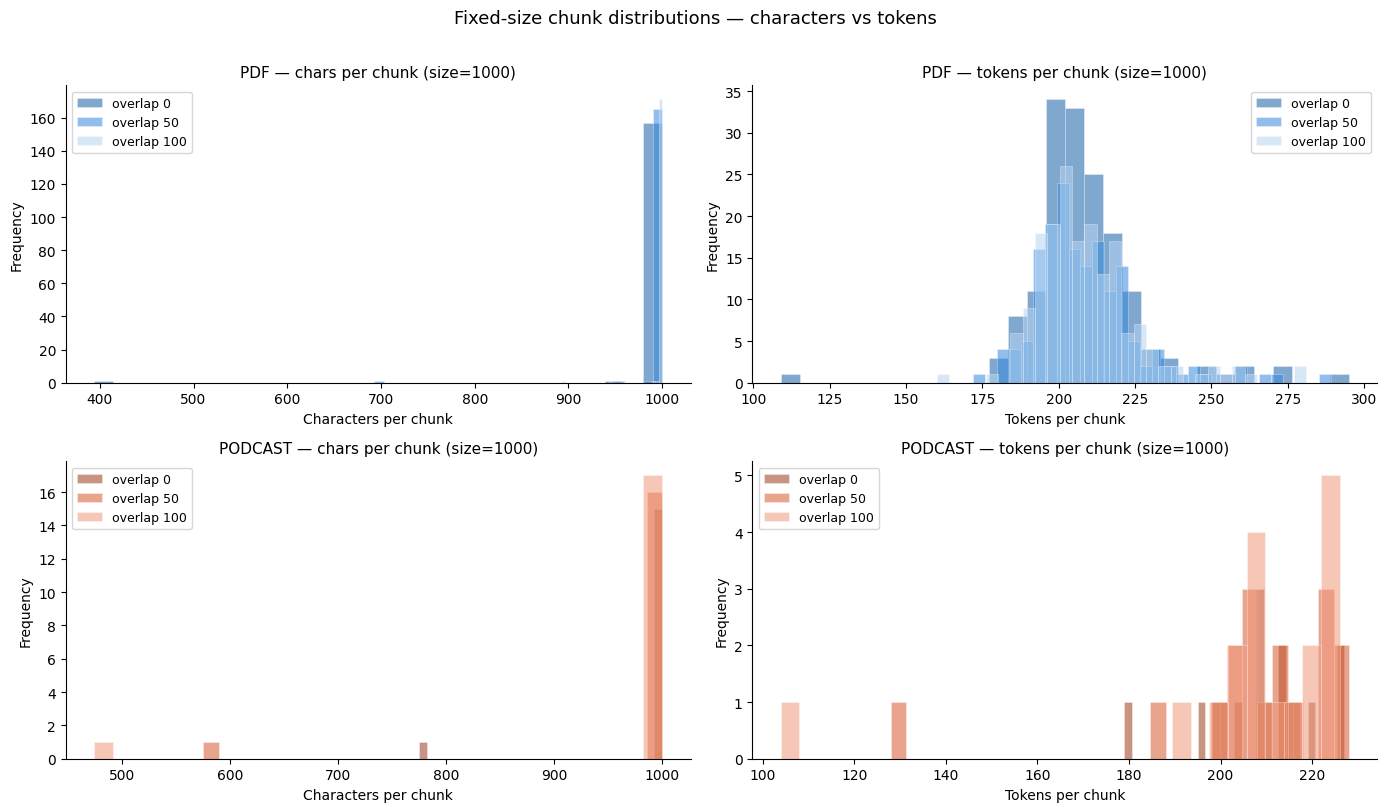

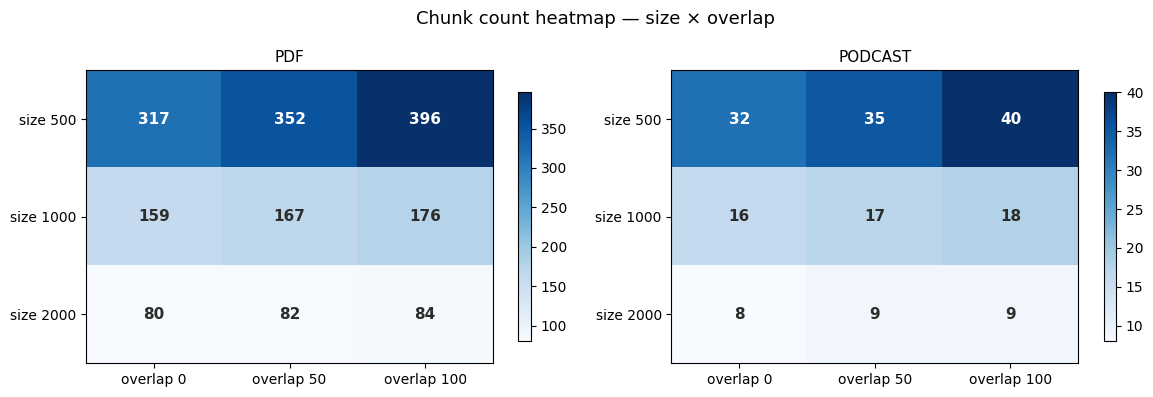

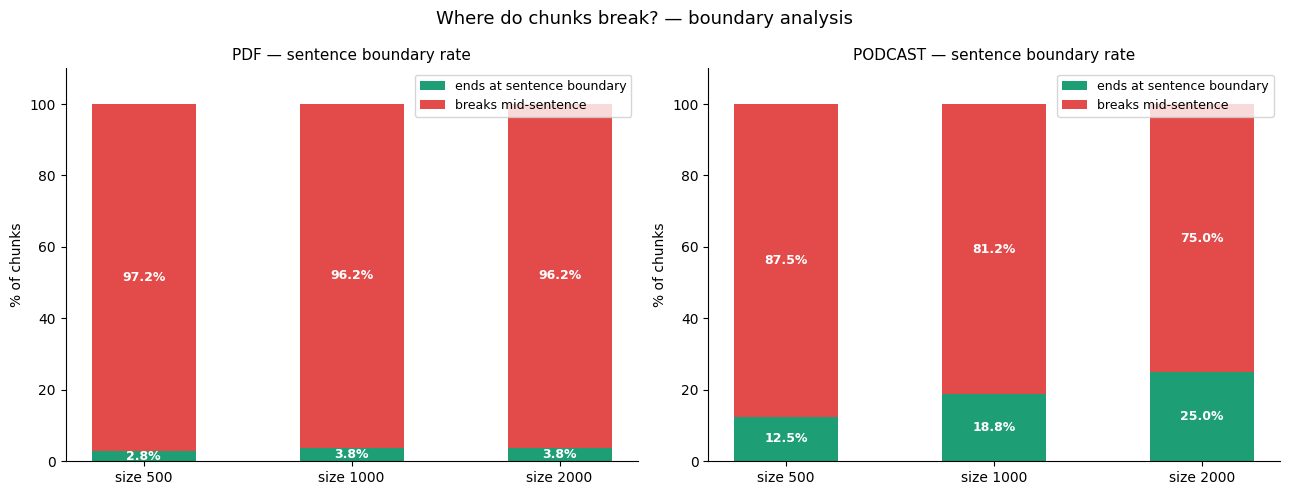

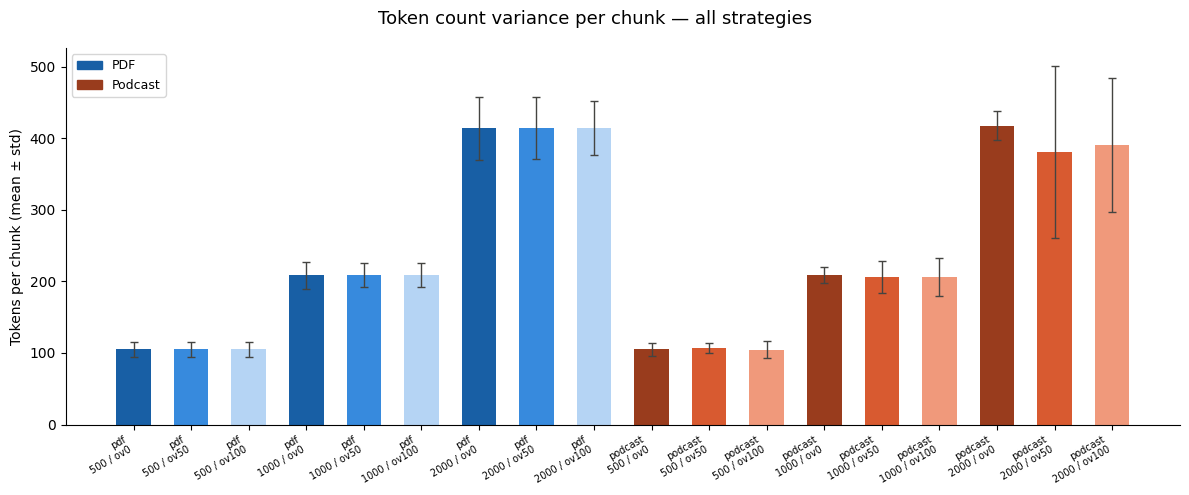

,Strategy,Chunk count,Token precision,Boundary quality,Context coverage,Best for
0,"Fixed / small (500, ov=0)",High,Low,Poor,Narrow,"High-precision retrieval, short answers"
1,"Fixed / small (500, ov=100)",Very high,Low,Poor,Overlapping,Retrieval where boundary context matters
2,"Fixed / large (2000, ov=0)",Low,Low,Fair,Broad,"Summarisation, broad topic retrieval"
3,"Fixed / large (2000, ov=100)",Low,Low,Fair,Overlapping,Summarisation with overlap safety net



Key finding: fixed-size chunking never achieves token precision.
For production RAG, combine recursive splitting + tiktoken token verification.


In [11]:
# ============================================================
# STEP 1: Imports & Setup
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import re
import tiktoken
from pathlib import Path

encoding = tiktoken.get_encoding("cl100k_base")

def count_tokens(text: str) -> int:
    return len(encoding.encode(text))

# ============================================================
# STEP 2: Enriched Statistics Table
# ============================================================
def compute_chunk_stats(chunks: list[str], doc_name: str, strategy: str,
                         chunk_size: int, chunk_overlap: int) -> dict:
    if not chunks:
        return {}

    char_lengths  = [len(c) for c in chunks]
    token_counts  = [count_tokens(c) for c in chunks]

    # Boundary break analysis
    mid_sentence  = sum(1 for c in chunks if c and not c.strip()[-1] in ".!?\"'")
    mid_word      = sum(1 for c in chunks if c and not c[-1].isspace() and not c[-1] in ".!?,;:")
    para_break    = sum(1 for c in chunks if c.strip().endswith("\n\n") or c.strip().startswith("\n\n"))
    sentence_end  = len(chunks) - mid_sentence

    return {
        "document":             doc_name,
        "strategy":             strategy,
        "chunk_size":           chunk_size,
        "chunk_overlap":        chunk_overlap,
        "num_chunks":           len(chunks),
        "avg_chars":            round(np.mean(char_lengths), 1),
        "std_chars":            round(np.std(char_lengths), 1),
        "min_chars":            min(char_lengths),
        "max_chars":            max(char_lengths),
        "avg_tokens":           round(np.mean(token_counts), 1),
        "std_tokens":           round(np.std(token_counts), 1),
        "min_tokens":           min(token_counts),
        "max_tokens":           max(token_counts),
        "pct_mid_sentence":     round(mid_sentence  / len(chunks) * 100, 1),
        "pct_sentence_end":     round(sentence_end  / len(chunks) * 100, 1),
        "pct_para_break":       round(para_break    / len(chunks) * 100, 1),
        "token_variance_pct":   round(np.std(token_counts) / np.mean(token_counts) * 100, 1),
    }

stats_rows = []
for chunk_key, chunks in fixed_size_chunks.items():
    parts        = chunk_key.split("_")           # e.g. podcast_size_500_overlap_0
    doc_name     = parts[0]
    chunk_size   = int(parts[2])
    chunk_overlap = int(parts[4])
    stats_rows.append(
        compute_chunk_stats(chunks, doc_name, "fixed", chunk_size, chunk_overlap)
    )

stats_df = pd.DataFrame(stats_rows).sort_values(["document", "chunk_size", "chunk_overlap"])
display(stats_df)

# ============================================================
# STEP 3: Helper — colour palette
# ============================================================
COLORS = {
    "pdf_0":    "#185FA5",
    "pdf_50":   "#378ADD",
    "pdf_100":  "#B5D4F4",
    "podcast_0":   "#993C1D",
    "podcast_50":  "#D85A30",
    "podcast_100": "#F0997B",
}

def chunk_color(doc, overlap):
    return COLORS.get(f"{doc}_{overlap}", "#888780")

# ============================================================
# STEP 4: Figure 1 — Chunk Size Distribution (char + token)
# ============================================================
fig1, axes = plt.subplots(2, 2, figsize=(14, 8))
fig1.suptitle("Fixed-size chunk distributions — characters vs tokens", fontsize=13, y=1.01)

for row_idx, doc in enumerate(["pdf", "podcast"]):
    for col_idx, metric in enumerate(["chars", "tokens"]):
        ax = axes[row_idx][col_idx]
        for overlap in [0, 50, 100]:
            key    = f"{doc}_size_1000_overlap_{overlap}"
            chunks = fixed_size_chunks.get(key, [])
            if not chunks:
                continue
            values = [len(c) for c in chunks] if metric == "chars" else [count_tokens(c) for c in chunks]
            ax.hist(values, bins=30, alpha=0.55,
                    color=chunk_color(doc, overlap),
                    label=f"overlap {overlap}",
                    edgecolor="white", linewidth=0.4)

        ax.set_title(f"{doc.upper()} — {metric} per chunk (size=1000)", fontsize=11)
        ax.set_xlabel(f"{'Characters' if metric == 'chars' else 'Tokens'} per chunk", fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)
        ax.legend(fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig1_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# STEP 5: Figure 2 — Chunk Count Heatmap (size × overlap)
# ============================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle("Chunk count heatmap — size × overlap", fontsize=13)

for ax, doc in zip(axes2, ["pdf", "podcast"]):
    matrix = []
    for size in [500, 1000, 2000]:
        row = []
        for overlap in [0, 50, 100]:
            key = f"{doc}_size_{size}_overlap_{overlap}"
            row.append(len(fixed_size_chunks.get(key, [])))
        matrix.append(row)

    matrix_np = np.array(matrix)
    im = ax.imshow(matrix_np, cmap="Blues", aspect="auto")
    ax.set_xticks([0, 1, 2]);  ax.set_xticklabels(["overlap 0", "overlap 50", "overlap 100"])
    ax.set_yticks([0, 1, 2]);  ax.set_yticklabels(["size 500", "size 1000", "size 2000"])
    ax.set_title(doc.upper(), fontsize=11)

    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(matrix_np[i, j]),
                    ha="center", va="center",
                    color="white" if matrix_np[i, j] > matrix_np.max() * 0.6 else "#2C2C2A",
                    fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()
plt.savefig("fig2_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# STEP 6: Figure 3 — Boundary Break Analysis (stacked bar)
# ============================================================
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("Where do chunks break? — boundary analysis", fontsize=13)

for ax, doc in zip(axes3, ["pdf", "podcast"]):
    labels, pct_sent, pct_mid = [], [], []

    for size in [500, 1000, 2000]:
        key    = f"{doc}_size_{size}_overlap_0"
        chunks = fixed_size_chunks.get(key, [])
        if not chunks:
            continue
        mid  = sum(1 for c in chunks if c and c.strip() and c.strip()[-1] not in ".!?\"'")
        good = len(chunks) - mid
        labels.append(f"size {size}")
        pct_sent.append(round(good / len(chunks) * 100, 1))
        pct_mid.append(round(mid  / len(chunks) * 100, 1))

    x = np.arange(len(labels))
    b1 = ax.bar(x, pct_sent, color="#1D9E75", label="ends at sentence boundary", width=0.5)
    b2 = ax.bar(x, pct_mid,  bottom=pct_sent, color="#E24B4A",
                label="breaks mid-sentence", width=0.5)

    ax.set_xticks(x);  ax.set_xticklabels(labels)
    ax.set_ylim(0, 110)
    ax.set_ylabel("% of chunks", fontsize=10)
    ax.set_title(f"{doc.upper()} — sentence boundary rate", fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    for rect, val in zip(b1.patches, pct_sent):
        ax.text(rect.get_x() + rect.get_width() / 2,
                rect.get_height() / 2, f"{val}%",
                ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    for rect, val in zip(b2.patches, pct_mid):
        ax.text(rect.get_x() + rect.get_width() / 2,
                rect.get_y() + rect.get_height() / 2, f"{val}%",
                ha="center", va="center", fontsize=9, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig("fig3_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# STEP 7: Figure 4 — Token Variance Across Strategies
# ============================================================
fig4, ax4 = plt.subplots(figsize=(12, 5))
fig4.suptitle("Token count variance per chunk — all strategies", fontsize=13)

x_labels, means, stds, colors_bar = [], [], [], []
for _, row in stats_df.iterrows():
    x_labels.append(f"{row['document']}\n{row['chunk_size']} / ov{row['chunk_overlap']}")
    means.append(row["avg_tokens"])
    stds.append(row["std_tokens"])
    colors_bar.append(chunk_color(row["document"], row["chunk_overlap"]))

x = np.arange(len(x_labels))
ax4.bar(x, means, yerr=stds, color=colors_bar, width=0.6,
        capsize=3, error_kw={"elinewidth": 1, "ecolor": "#444441"})
ax4.set_xticks(x)
ax4.set_xticklabels(x_labels, fontsize=7, rotation=30, ha="right")
ax4.set_ylabel("Tokens per chunk (mean ± std)", fontsize=10)
ax4.spines[["top", "right"]].set_visible(False)

pdf_patch     = mpatches.Patch(color="#185FA5", label="PDF")
podcast_patch = mpatches.Patch(color="#993C1D", label="Podcast")
ax4.legend(handles=[pdf_patch, podcast_patch], fontsize=9)

plt.tight_layout()
plt.savefig("fig4_token_variance.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# STEP 8: Trade-off Summary Table
# ============================================================
tradeoff_data = {
    "Strategy":         ["Fixed / small (500, ov=0)",  "Fixed / small (500, ov=100)",
                         "Fixed / large (2000, ov=0)", "Fixed / large (2000, ov=100)"],
    "Chunk count":      ["High",   "Very high", "Low",  "Low"],
    "Token precision":  ["Low",    "Low",       "Low",  "Low"],
    "Boundary quality": ["Poor",   "Poor",      "Fair", "Fair"],
    "Context coverage": ["Narrow", "Overlapping","Broad","Overlapping"],
    "Best for":         [
        "High-precision retrieval, short answers",
        "Retrieval where boundary context matters",
        "Summarisation, broad topic retrieval",
        "Summarisation with overlap safety net",
    ],
}

tradeoff_df = pd.DataFrame(tradeoff_data)
display(tradeoff_df)
print("\nKey finding: fixed-size chunking never achieves token precision.")
print("For production RAG, combine recursive splitting + tiktoken token verification.")

### Step 7: Analyze Chunk Quality

,document,strategy,chunk_size,chunk_overlap,num_chunks,pct_end_mid_sentence,pct_start_mid_sentence,avg_incomplete_sents,pct_end_mid_paragraph,pct_start_mid_paragraph,continuity_score,quality_score
0,pdf,fixed,500,0,317,97.2,90.5,0.97,100.0,100.0,40.5,3.0
1,pdf,fixed,500,50,352,98.0,86.1,0.98,100.0,100.0,99.4,3.6
2,pdf,fixed,500,100,396,97.7,88.6,0.98,100.0,100.0,41.8,3.2
3,pdf,fixed,1000,0,159,96.2,89.3,0.97,100.0,100.0,39.9,3.6
4,pdf,fixed,1000,50,167,97.0,93.4,0.98,100.0,100.0,100.0,2.5
5,pdf,fixed,1000,100,176,97.2,85.8,0.97,100.0,100.0,41.1,4.0
6,pdf,fixed,2000,0,80,96.2,91.2,0.98,100.0,100.0,38.0,3.2
7,pdf,fixed,2000,50,82,98.8,93.9,0.99,100.0,100.0,100.0,1.7
8,pdf,fixed,2000,100,84,98.8,94.0,0.99,100.0,100.0,42.2,1.7
9,pdf,recursive_default,500,200,500,69.4,65.4,0.69,100.0,100.0,43.5,19.2


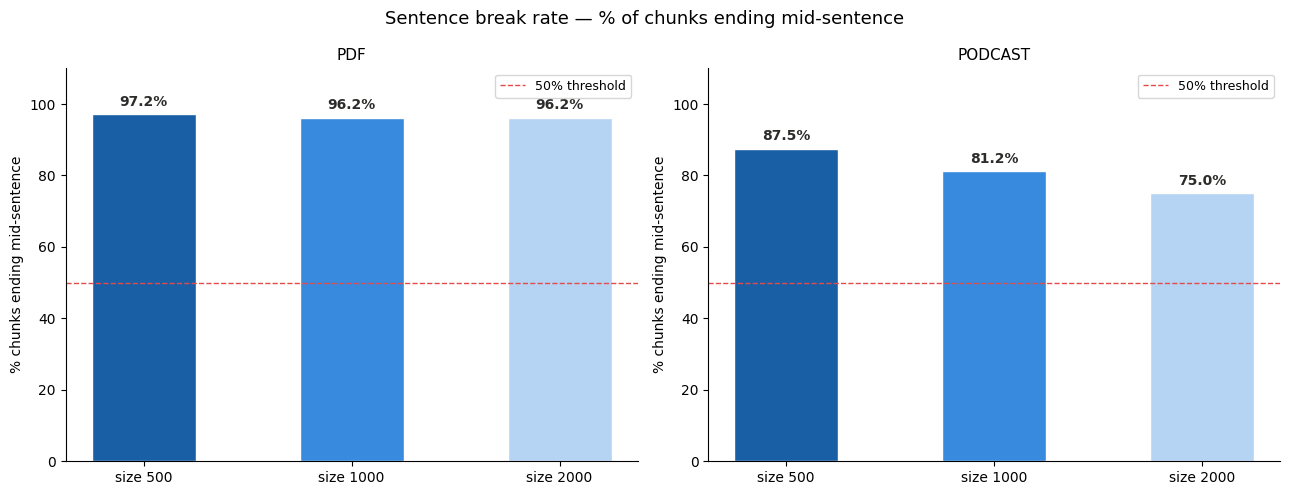

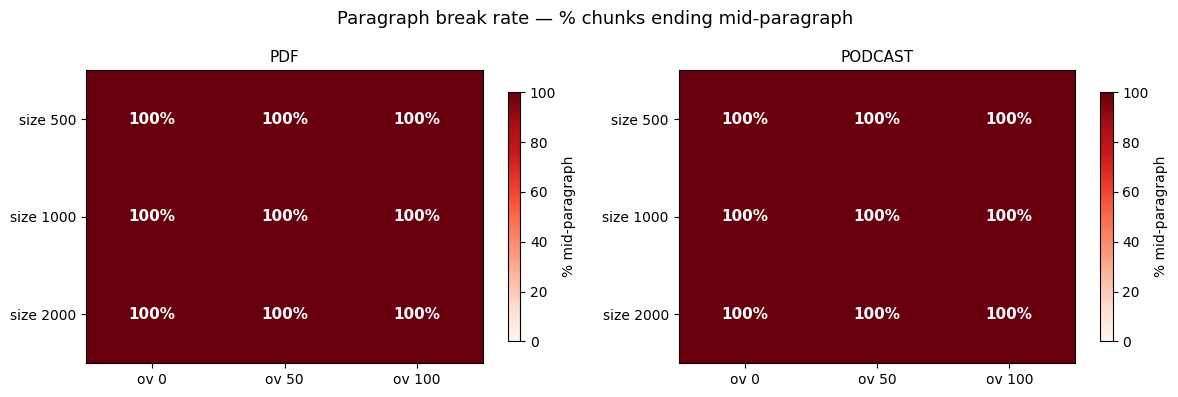

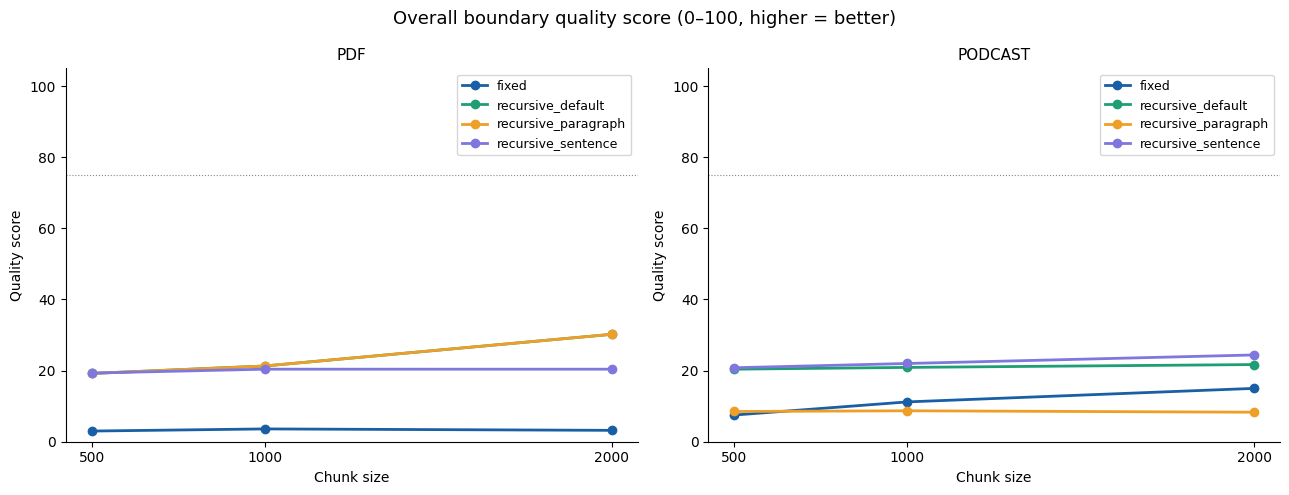

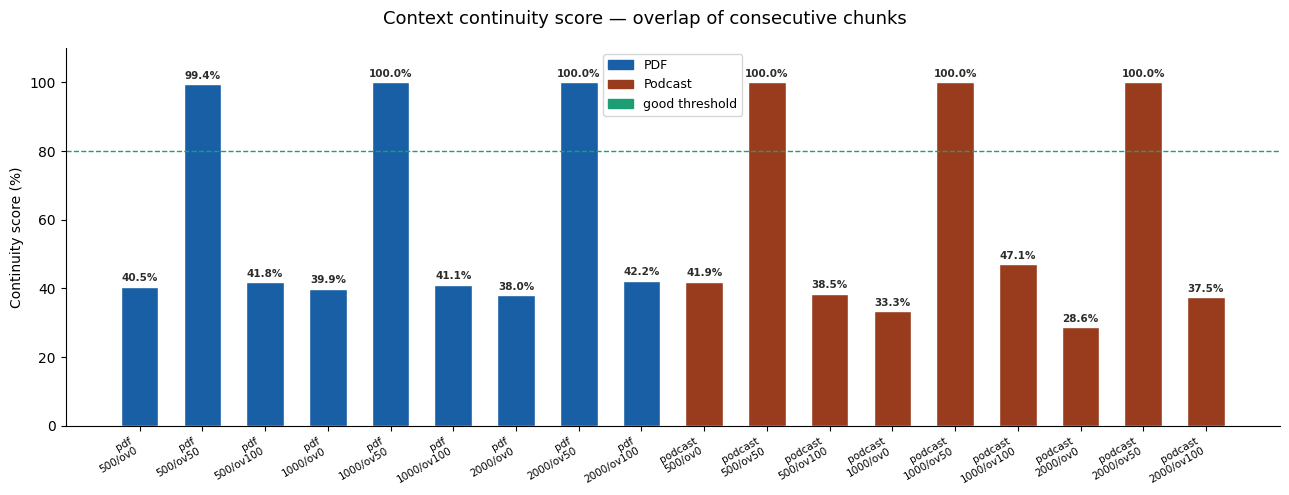

BOUNDARY QUALITY SUMMARY — best strategy per document

PDF
  Best strategy : recursive_default
  Chunk size    : 2000
  Chunk overlap : 200
  Quality score : 30.2/100
  Mid-sentence  : 53.8% of chunks
  Mid-paragraph : 100.0% of chunks
  Continuity    : 32.0%

PODCAST
  Best strategy : recursive_sentence
  Chunk size    : 2000
  Chunk overlap : 200
  Quality score : 24.4/100
  Mid-sentence  : 88.9% of chunks
  Mid-paragraph : 100.0% of chunks
  Continuity    : 37.5%


In [12]:
# ============================================================
# STEP 1: Imports & Setup
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

def count_tokens(text: str) -> int:
    return len(encoding.encode(text))

# ============================================================
# STEP 2: Boundary Detection Functions
# ============================================================

def ends_mid_sentence(chunk: str) -> bool:
    """True if chunk ends before a sentence boundary."""
    text = chunk.strip()
    if not text:
        return False
    return text[-1] not in ".!?\"'"

def starts_mid_sentence(chunk: str) -> bool:
    """True if chunk starts mid-sentence (no capital after boundary)."""
    text = chunk.strip()
    if not text:
        return False
    return text[0].islower()

def ends_mid_paragraph(chunk: str) -> bool:
    """True if chunk ends without a paragraph break."""
    return not chunk.rstrip().endswith("\n\n")

def starts_mid_paragraph(chunk: str) -> bool:
    """True if chunk starts in the middle of a paragraph."""
    return not chunk.startswith("\n\n") and not chunk.startswith("\n")

def count_incomplete_sentences(chunk: str) -> int:
    """Count sentences that are cut mid-way (no ending punctuation)."""
    sentences = re.split(r'(?<=[.!?])\s+', chunk.strip())
    return sum(1 for s in sentences if s and s[-1] not in ".!?")

def context_continuity_score(chunks: list[str]) -> float:
    """
    Score 0-100: measures how well consecutive chunks share
    overlapping context. Higher = better continuity.
    Uses last 50 chars of chunk N vs first 50 chars of chunk N+1.
    """
    if len(chunks) < 2:
        return 100.0
    continuity_hits = 0
    for i in range(len(chunks) - 1):
        tail  = chunks[i].strip()[-50:]
        head  = chunks[i + 1].strip()[:50]
        shared_words = set(tail.lower().split()) & set(head.lower().split())
        if shared_words:
            continuity_hits += 1
    return round(continuity_hits / (len(chunks) - 1) * 100, 1)

# ============================================================
# STEP 3: Full Boundary Quality Audit per Chunk Set
# ============================================================

def audit_boundary_quality(chunks: list[str], doc_name: str,
                             strategy: str, chunk_size: int,
                             chunk_overlap: int) -> dict:
    if not chunks:
        return {}

    n = len(chunks)

    mid_sent_end   = [ends_mid_sentence(c)    for c in chunks]
    mid_sent_start = [starts_mid_sentence(c)  for c in chunks]
    mid_para_end   = [ends_mid_paragraph(c)   for c in chunks]
    mid_para_start = [starts_mid_paragraph(c) for c in chunks]
    incomplete     = [count_incomplete_sentences(c) for c in chunks]

    return {
        "document":               doc_name,
        "strategy":               strategy,
        "chunk_size":             chunk_size,
        "chunk_overlap":          chunk_overlap,
        "num_chunks":             n,

        # Sentence boundary metrics
        "pct_end_mid_sentence":   round(sum(mid_sent_end)   / n * 100, 1),
        "pct_start_mid_sentence": round(sum(mid_sent_start) / n * 100, 1),
        "avg_incomplete_sents":   round(np.mean(incomplete), 2),

        # Paragraph boundary metrics
        "pct_end_mid_paragraph":  round(sum(mid_para_end)   / n * 100, 1),
        "pct_start_mid_paragraph":round(sum(mid_para_start) / n * 100, 1),

        # Context continuity
        "continuity_score":       context_continuity_score(chunks),

        # Overall quality score (0-100, higher = better)
        "quality_score":          round(
            100
            - (sum(mid_sent_end)   / n * 40)   # sentence end break — highest penalty
            - (sum(mid_sent_start) / n * 20)   # sentence start break
            - (sum(mid_para_end)   / n * 25)   # paragraph end break
            - (sum(mid_para_start) / n * 15),  # paragraph start break
            1
        ),
    }

# ============================================================
# STEP 4: Run Audit Across All Chunk Sets
# ============================================================

audit_rows = []

# Fixed-size chunks
for chunk_key, chunks in fixed_size_chunks.items():
    parts = chunk_key.split("_")          # podcast_size_500_overlap_0
    doc_name      = parts[0]
    chunk_size    = int(parts[2])
    chunk_overlap = int(parts[4])
    audit_rows.append(audit_boundary_quality(
        chunks, doc_name, "fixed", chunk_size, chunk_overlap
    ))

# Recursive chunks (if available from previous exercise)
if "recursive_chunks" in dir() or "recursive_chunks" in globals():
    for chunk_key, chunks in recursive_chunks.items():
        parts = chunk_key.split("_")      # podcast_default_size_500
        doc_name  = parts[0]
        strategy  = parts[1]
        chunk_size = int(parts[3])
        audit_rows.append(audit_boundary_quality(
            chunks, doc_name, f"recursive_{strategy}", chunk_size, chunk_overlap=200
        ))

audit_df = pd.DataFrame(audit_rows).sort_values(
    ["document", "strategy", "chunk_size", "chunk_overlap"]
).reset_index(drop=True)

display(audit_df)

# ============================================================
# STEP 5: Figure 1 — Sentence Break Rate by Strategy & Size
# ============================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(13, 5))
fig1.suptitle("Sentence break rate — % of chunks ending mid-sentence", fontsize=13)

for ax, doc in zip(axes1, ["pdf", "podcast"]):
    subset = audit_df[
        (audit_df["document"] == doc) &
        (audit_df["strategy"] == "fixed") &
        (audit_df["chunk_overlap"] == 0)
    ].sort_values("chunk_size")

    x      = np.arange(len(subset))
    labels = [f"size {r}" for r in subset["chunk_size"]]

    bars = ax.bar(x, subset["pct_end_mid_sentence"],
                  color=["#185FA5", "#378ADD", "#B5D4F4"],
                  width=0.5, edgecolor="white")

    ax.axhline(50, color="#E24B4A", linewidth=1,
               linestyle="--", label="50% threshold")
    ax.set_xticks(x);  ax.set_xticklabels(labels)
    ax.set_ylim(0, 110)
    ax.set_ylabel("% chunks ending mid-sentence", fontsize=10)
    ax.set_title(f"{doc.upper()}", fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    for bar, val in zip(bars, subset["pct_end_mid_sentence"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5, f"{val}%",
                ha="center", va="bottom", fontsize=10, fontweight="bold",
                color="#2C2C2A")

plt.tight_layout()
plt.savefig("fig1_sentence_breaks.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# STEP 6: Figure 2 — Paragraph Break Rate Heatmap
# ============================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle("Paragraph break rate — % chunks ending mid-paragraph", fontsize=13)

for ax, doc in zip(axes2, ["pdf", "podcast"]):
    subset = audit_df[
        (audit_df["document"] == doc) &
        (audit_df["strategy"] == "fixed")
    ].sort_values(["chunk_size", "chunk_overlap"])

    sizes    = sorted(subset["chunk_size"].unique())
    overlaps = sorted(subset["chunk_overlap"].unique())
    matrix   = np.zeros((len(sizes), len(overlaps)))

    for i, size in enumerate(sizes):
        for j, overlap in enumerate(overlaps):
            val = subset[
                (subset["chunk_size"] == size) &
                (subset["chunk_overlap"] == overlap)
            ]["pct_end_mid_paragraph"].values
            matrix[i, j] = val[0] if len(val) else 0

    im = ax.imshow(matrix, cmap="Reds", aspect="auto", vmin=0, vmax=100)
    ax.set_xticks(range(len(overlaps)))
    ax.set_xticklabels([f"ov {o}" for o in overlaps])
    ax.set_yticks(range(len(sizes)))
    ax.set_yticklabels([f"size {s}" for s in sizes])
    ax.set_title(f"{doc.upper()}", fontsize=11)

    for i in range(len(sizes)):
        for j in range(len(overlaps)):
            ax.text(j, i, f"{matrix[i, j]:.0f}%",
                    ha="center", va="center", fontsize=11, fontweight="bold",
                    color="white" if matrix[i, j] > 60 else "#2C2C2A")

    plt.colorbar(im, ax=ax, shrink=0.85, label="% mid-paragraph")

plt.tight_layout()
plt.savefig("fig2_paragraph_breaks.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# STEP 7: Figure 3 — Overall Quality Score Comparison
# ============================================================
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("Overall boundary quality score (0–100, higher = better)", fontsize=13)

STRATEGY_COLORS = {
    "fixed":              "#185FA5",
    "recursive_default":  "#1D9E75",
    "recursive_paragraph":"#EF9F27",
    "recursive_sentence": "#7F77DD",
}

for ax, doc in zip(axes3, ["pdf", "podcast"]):
    subset = audit_df[
        (audit_df["document"] == doc) &
        (audit_df["chunk_overlap"].isin([0, 200]))
    ].sort_values(["strategy", "chunk_size"])

    for strategy, grp in subset.groupby("strategy"):
        grp = grp.sort_values("chunk_size")
        ax.plot(grp["chunk_size"], grp["quality_score"],
                marker="o", linewidth=2,
                color=STRATEGY_COLORS.get(strategy, "#888780"),
                label=strategy)

    ax.set_xticks([500, 1000, 2000])
    ax.set_xlabel("Chunk size", fontsize=10)
    ax.set_ylabel("Quality score", fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_title(f"{doc.upper()}", fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.axhline(75, color="#888780", linewidth=0.8,
               linestyle=":", label="acceptable threshold")

plt.tight_layout()
plt.savefig("fig3_quality_scores.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# STEP 8: Figure 4 — Context Continuity Score
# ============================================================
fig4, ax4 = plt.subplots(figsize=(13, 5))
fig4.suptitle("Context continuity score — overlap of consecutive chunks", fontsize=13)

subset_fixed = audit_df[
    (audit_df["strategy"] == "fixed")
].sort_values(["document", "chunk_size", "chunk_overlap"])

x_labels, scores, bar_colors = [], [], []
for _, row in subset_fixed.iterrows():
    x_labels.append(
        f"{row['document']}\n{row['chunk_size']}/ov{row['chunk_overlap']}"
    )
    scores.append(row["continuity_score"])
    bar_colors.append(
        "#185FA5" if row["document"] == "pdf" else "#993C1D"
    )

x = np.arange(len(x_labels))
bars = ax4.bar(x, scores, color=bar_colors, width=0.6, edgecolor="white")
ax4.set_xticks(x)
ax4.set_xticklabels(x_labels, fontsize=7.5, rotation=30, ha="right")
ax4.set_ylabel("Continuity score (%)", fontsize=10)
ax4.set_ylim(0, 110)
ax4.axhline(80, color="#1D9E75", linewidth=1,
            linestyle="--", label="good continuity threshold")
ax4.spines[["top", "right"]].set_visible(False)

pdf_patch     = mpatches.Patch(color="#185FA5", label="PDF")
podcast_patch = mpatches.Patch(color="#993C1D", label="Podcast")
ax4.legend(handles=[pdf_patch, podcast_patch,
           mpatches.Patch(color="#1D9E75", label="good threshold")],
           fontsize=9)

for bar, val in zip(bars, scores):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1, f"{val}%",
             ha="center", va="bottom", fontsize=7.5,
             color="#2C2C2A", fontweight="bold")

plt.tight_layout()
plt.savefig("fig4_continuity.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# STEP 9: Best Strategy Summary
# ============================================================
print("=" * 65)
print("BOUNDARY QUALITY SUMMARY — best strategy per document")
print("=" * 65)

for doc in ["pdf", "podcast"]:
    best = (
        audit_df[audit_df["document"] == doc]
        .sort_values("quality_score", ascending=False)
        .iloc[0]
    )
    print(f"\n{doc.upper()}")
    print(f"  Best strategy : {best['strategy']}")
    print(f"  Chunk size    : {best['chunk_size']}")
    print(f"  Chunk overlap : {best['chunk_overlap']}")
    print(f"  Quality score : {best['quality_score']}/100")
    print(f"  Mid-sentence  : {best['pct_end_mid_sentence']}% of chunks")
    print(f"  Mid-paragraph : {best['pct_end_mid_paragraph']}% of chunks")
    print(f"  Continuity    : {best['continuity_score']}%")

### Step 8: Make Recommendations

**See file:** chunking recommendations.md